#Trabajo Práctico 2 - Críticas Cinematográficas

#Grupo 2 - G2 - Integrantes:

- Calderan, Facundo Andres
- Merlinsky Camins, Mariano Gabriel
- Castellano Bogdan, Benjamin
- Pons Echeverria, Tomas

# Redes neuronales

In [ ]:
import pandas as pd

# Descargamos los archivos
!gdown 1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
!gdown 1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk

# Descargamos langid
!pip install langid
# Descargamos tensorflow Y transformers para el modelo BETO
!pip install transformers

!pip install tensorflow==2.19.0


Downloading...
From: https://drive.google.com/uc?id=1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 88.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk
To: /content/train.csv
100% 72.2M/72.2M [00:00<00:00, 93.9MB/s]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=73ae851f1e4cad77aada41925efcdf24d2bad3acb62c6e4b93bcf85863ff81f2
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [ ]:
# Cargamos los archivos en dataframes
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

print(data_train.info())
data_train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           50000 non-null  int64 
 1   review_es    50000 non-null  object
 2   sentimiento  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...,...
49995,49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,49998,Voy a tener que estar en desacuerdo con el com...,negativo


In [ ]:
import langid
import re
# Nos quedamos con las críticas en español
def detectar_idioma(texto):
    lang, prob = langid.classify(texto)
    return lang

data_train['idioma'] = data_train['review_es'].apply(detectar_idioma)

data_train = data_train[data_train['idioma'] == 'es']
data_train = data_train.drop('idioma', axis=1)

data_train['sentimiento'] = data_train['sentimiento'].map({'positivo': 1, 'negativo': 0})

data_train

,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,1
1,1,Una pequeña pequeña producción.La técnica de f...,1
2,2,Pensé que esta era una manera maravillosa de p...,1
3,3,"Básicamente, hay una familia donde un niño peq...",0
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",1
...,...,...,...
49995,49995,Pensé que esta película hizo un buen trabajo a...,1
49996,49996,"Mala parcela, mal diálogo, mala actuación, dir...",0
49997,49997,Soy católica enseñada en escuelas primarias pa...,0
49998,49998,Voy a tener que estar en desacuerdo con el com...,0


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def testear_clasificacion(y_train, y_test, y_train_pred, y_test_pred):
  # Métricas
  metrics = {
      "accuracy": [
          accuracy_score(y_train, y_train_pred),
          accuracy_score(y_test, y_test_pred)
      ],
      "precision": [
          precision_score(y_train, y_train_pred, pos_label='positivo'),
          precision_score(y_test, y_test_pred, pos_label='positivo')
      ],
      "recall": [
          recall_score(y_train, y_train_pred, pos_label='positivo'),
          recall_score(y_test, y_test_pred, pos_label='positivo')
      ],
      "f1_score": [
          f1_score(y_train, y_train_pred, pos_label='positivo'),
          f1_score(y_test, y_test_pred, pos_label='positivo')
      ]
  }

  # Crear tabla
  results = pd.DataFrame(metrics, index=["Train", "Test"])

  # Graficar tabla
  fig, ax = plt.subplots(figsize=(6, 2))
  ax.axis('off')
  ax.axis('tight')
  ax.table(cellText=results.round(3).values,
          colLabels=results.columns,
          rowLabels=results.index,
          loc='center')
  plt.title("Comparativa de métricas: Train vs Test", pad=10)
  plt.show()


  # Graficar Matriz de confusión
  cm = confusion_matrix(y_test, y_test_pred)
  ConfusionMatrixDisplay(cm).plot(cmap='Blues')
  plt.title("Matriz de confusión")
  plt.show()

In [ ]:
X = data_train['review_es']
y = data_train['sentimiento']
X_test = data_test['review_es']

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np


MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
BATCH_SIZE = 16
MAX_LEN = 128
EPOCHS = 3
LEARNING_RATE = 2e-5
NUM_LABELS = 2
PATIENCE = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def tokenizar(texto):
    return tokenizer(
        texto,
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors="tf"
)

train_tokenized = tokenizar(X_train.tolist())
val_tokenized = tokenizar(X_val.tolist())
test_tokenized = tokenizar(X_test.tolist())

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_tokenized),
    y_train
)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_tokenized),
    y_val
)).batch(BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/537M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [ ]:
modelo =  TFAutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )


optimizador = tf.optimizers.Adam(learning_rate=LEARNING_RATE)

modelo.compile(
        optimizer=optimizador,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True
    )
with tf.device('/GPU:0'):
    history = modelo.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping]
    )

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
2409/2409 [==============================] - 1177s 464ms/step - loss: 0.3388 - accuracy: 0.8482 - val_loss: 0.3225 - val_accuracy: 0.8566
Epoch 2/3
2409/2409 [==============================] - 1108s 460ms/step - loss: 0.1985 - accuracy: 0.9202 - val_loss: 0.3775 - val_accuracy: 0.8771
Epoch 3/3
2409/2409 [==============================] - 1107s 460ms/step - loss: 0.1115 - accuracy: 0.9593 - val_loss: 0.4226 - val_accuracy: 0.8698


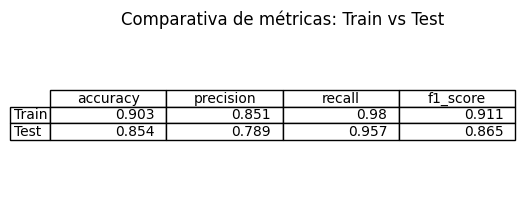

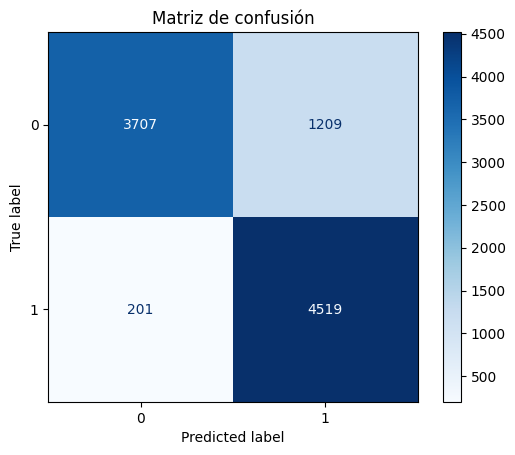

In [8]:
def obtener_predicciones(model, dataset):
    y_pred = []
    for batch in dataset:
        inputs, labels = batch
        logits = model(inputs, training=False).logits
        preds = tf.argmax(logits, axis=1).numpy()
        y_pred.extend(preds)
    return np.array(y_pred)

def convertir_a_labels(y):
    return np.where(y == 1, "positivo", "negativo")

# Dataset de entrenamiento y test (ya tokenizados)
y_train_pred = obtener_predicciones(modelo, train_dataset)
y_val_pred = obtener_predicciones(modelo, val_dataset)

# Convertimos a etiquetas
y_train_labels = convertir_a_labels(y_train)
y_val_labels = convertir_a_labels(y_val)
y_train_pred_labels = convertir_a_labels(y_train_pred)
y_val_pred_labels = convertir_a_labels(y_val_pred)

# Calculamos métricas
testear_clasificacion(
    y_train_labels,
    y_val_labels,
    y_train_pred_labels,
    y_val_pred_labels
)


In [9]:
#predecimos del test
predicciones = modelo.predict(test_tokenized)

# Convertir logits a probabilidades
probabilidades = tf.nn.softmax(predicciones.logits, axis=1)

# Obtener la clase más probable
clases = tf.argmax(probabilidades, axis=1).numpy()

etiquetas = ["negativo" if c == 0 else "positivo" for c in clases]
data_test['sentimiento'] = etiquetas

data_test = data_test.drop("review_es", axis=1)
data_test.to_csv('submission.csv', index=False)

269/269 [==============================] - 76s 274ms/step


In [10]:
import joblib

# Guardar el modelo
joblib.dump(modelo, 'bert_sentiment_model.joblib')

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


['bert_sentiment_model.joblib']